# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import math


import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load and View Data**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# **Feature Transformation**

In [8]:
from ast import NotIn
df_transformed = df.copy()
# Function to handle log transformation for skewed data
def log_transform_skewed(column):
    # For positive and zero values (log1p avoids log(0) errors)
    transformed = np.where(column >= 0, np.log1p(column), -np.log1p(-column))
    return transformed

# Compute skewness before transformation
skewness_before = df.skew()

# Apply transformation to skewed columns
features = df.columns.difference(['Class'])
for col in features:
    if abs(df[col].skew()) > 0.75:  # Threshold for skewness
        df_transformed[col] = log_transform_skewed(df[col])

# Compute skewness after transformation
skewness_after = df_transformed.skew()

# Compare skewness before and after
skewness_comparison = pd.DataFrame({
    'Skewness Before': skewness_before,
    'Skewness After': skewness_after
})

# Print the comparison
skewness_comparison

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Skewness Before,Skewness After
Time,-0.035568,-0.035568
V1,-3.280667,-0.364893
V2,-4.624866,-0.310128
V3,-2.240155,-0.315192
V4,0.676292,0.676292
V5,-2.425901,0.139077
V6,1.826581,0.804345
V7,2.553907,-0.112666
V8,-8.521944,-0.912642
V9,0.554680,0.554680


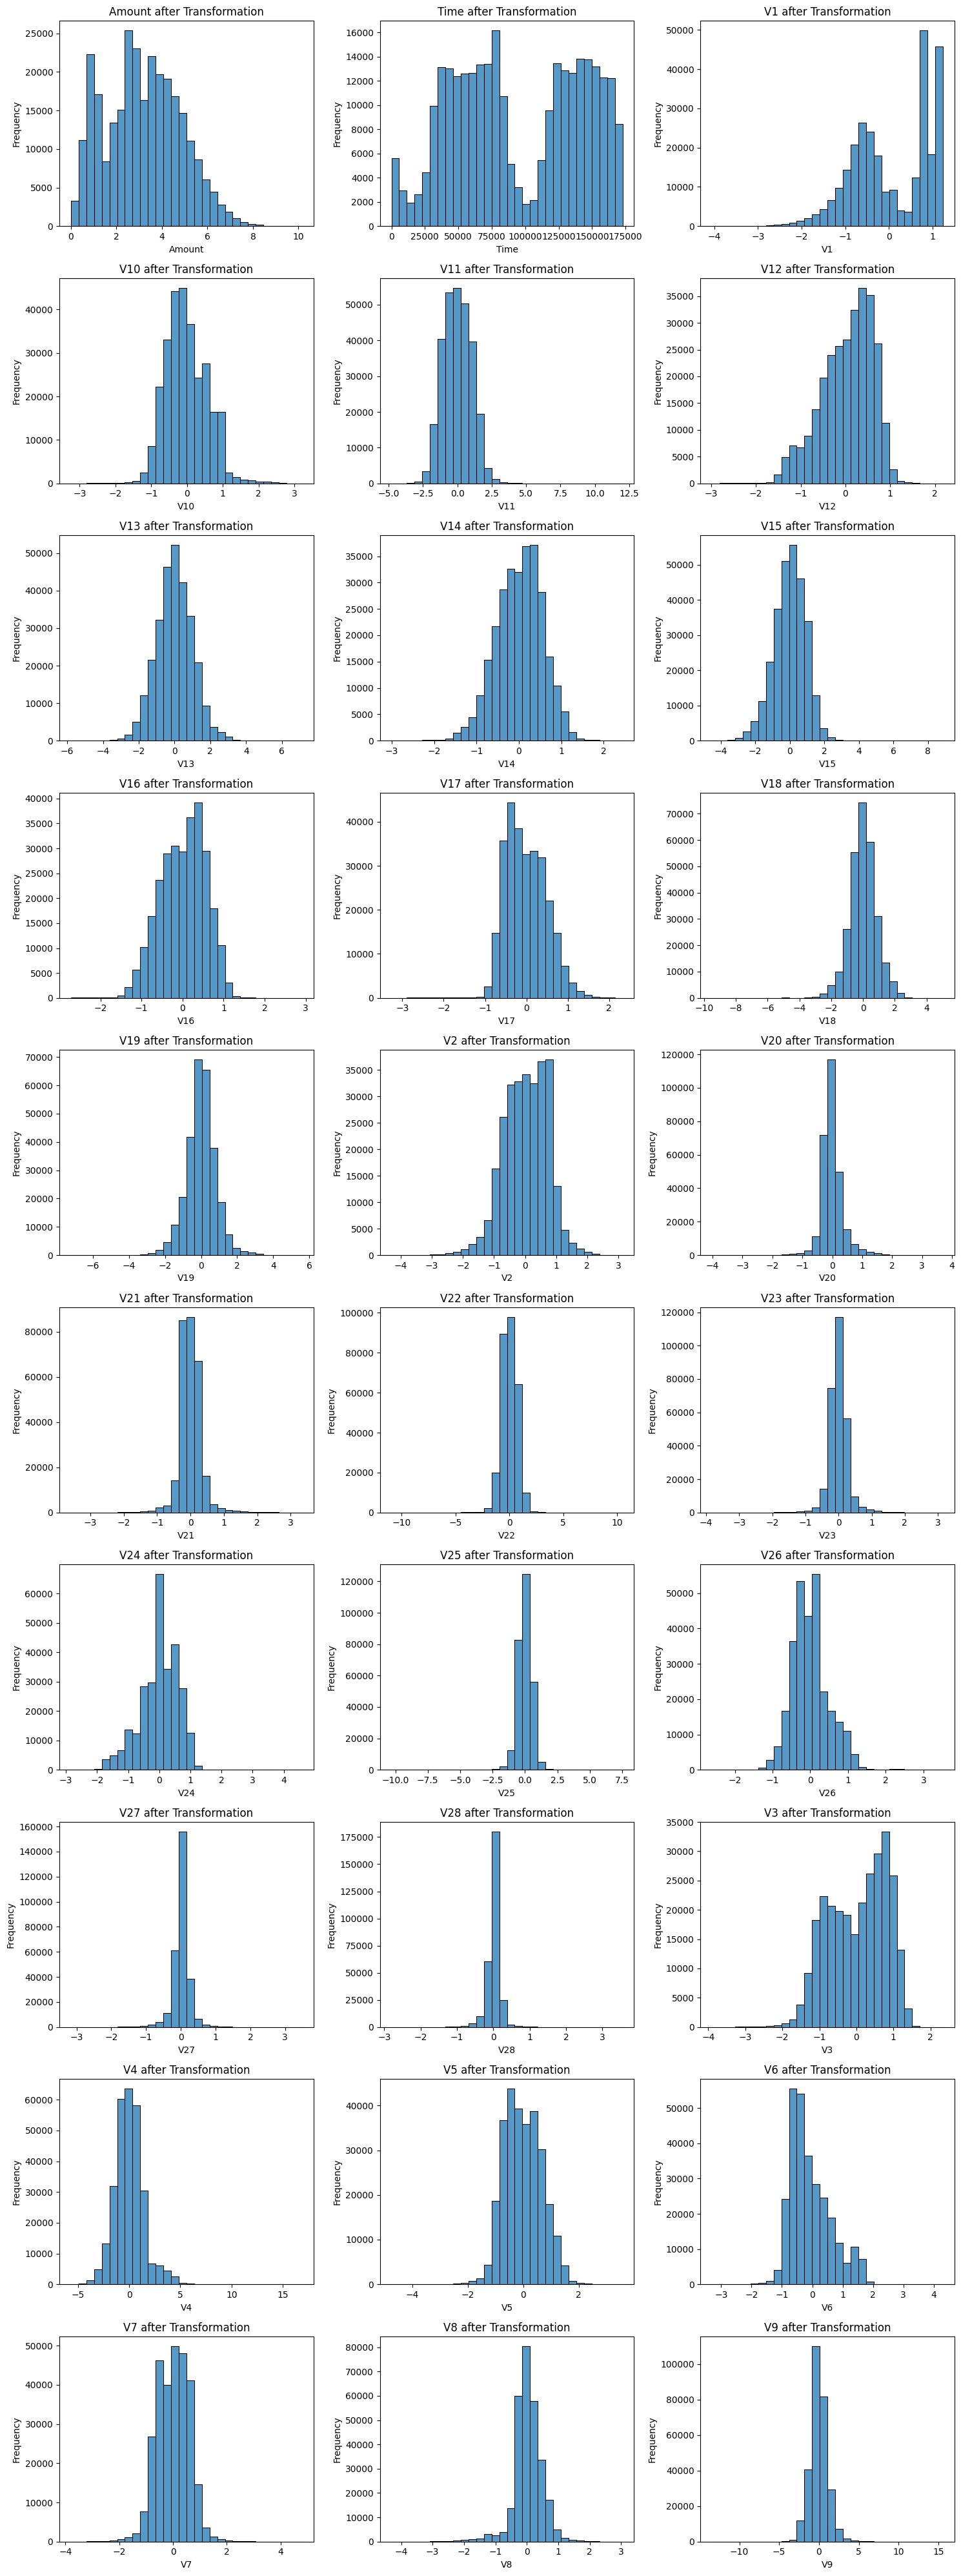

In [9]:
fig, axes = plt.subplots(10, 3, figsize=(15, 40))

# Flatten axes array to loop through easily
axes = axes.flatten()

# Plot each feature in a separate subplot
for i, feature in enumerate(features):
    sns.histplot(df_transformed[feature], ax=axes[i], kde=False, bins=30)
    axes[i].set_title(f'{feature} after Transformation')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots if features < 30
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# **Feature Engineering**

## **Time**

In [10]:
df_transformed['Day'], temp = df_transformed['Time'] // (24*60*60), df_transformed['Time'] % (24*60*60)
df_transformed['Hour'], temp = temp // (60*60), temp % (60*60)
df_transformed['Minute'], df_transformed['Second'] = temp // 60, temp % 60
df_transformed[['Time', 'Day', 'Hour', 'Minute', 'Second']].head(-1)

,Time,Day,Hour,Minute,Second
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,2.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...
284801,172785.0,1.0,23.0,59.0,45.0
284802,172786.0,1.0,23.0,59.0,46.0
284803,172787.0,1.0,23.0,59.0,47.0
284804,172788.0,1.0,23.0,59.0,48.0


### **Visualization**

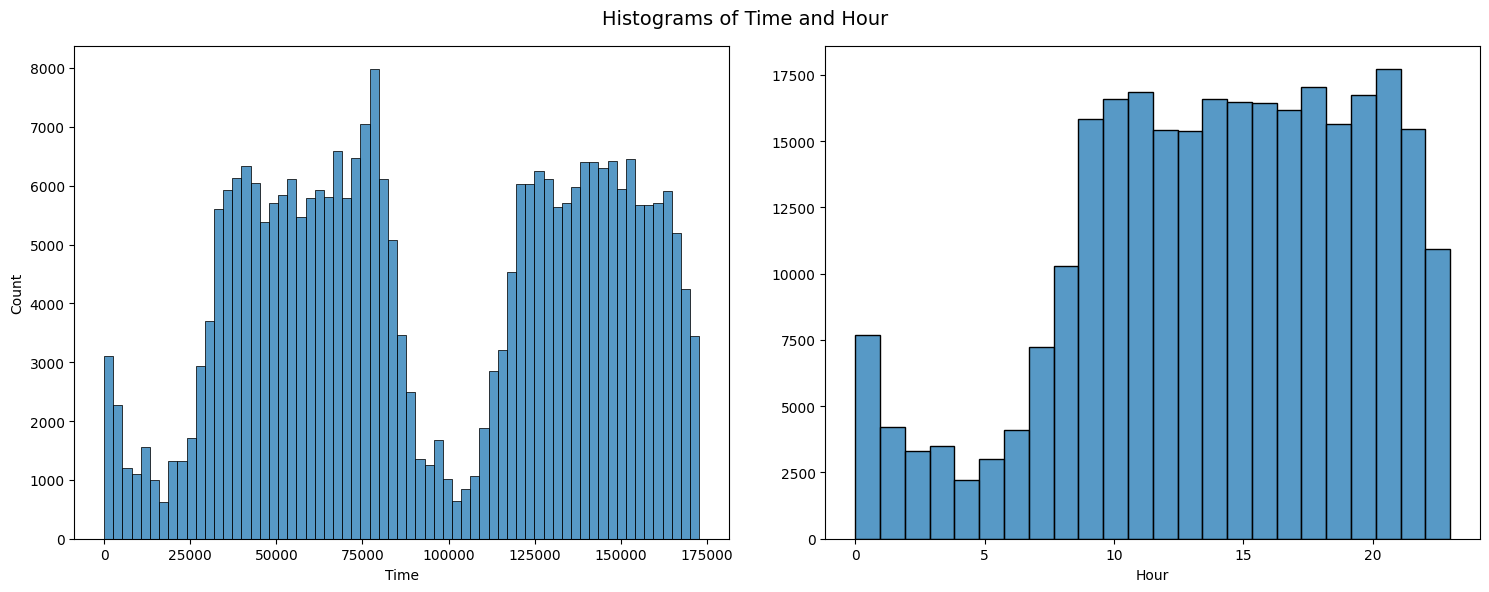

In [11]:
bins_df = math.floor(len(df_transformed)**(1/3))
fig, ax = plt.subplots(1, 2, figsize = (15, 6), sharey = False)
sns.histplot(data = df_transformed, x = 'Time', bins = bins_df, ax = ax[0])
sns.histplot(data = df_transformed, x = 'Hour', bins = 24, ax = ax[1])
ax[1].set_ylabel(" ")
plt.suptitle("Histograms of Time and Hour", size = 14)
plt.tight_layout()
plt.show()

## **Discard unnecessary features**

In [12]:
df_transformed.drop(['Time', 'Day', 'Minute', 'Second'], axis = 1, inplace = True)

# **Feature Selection**

## **Comparison of feature distributions**

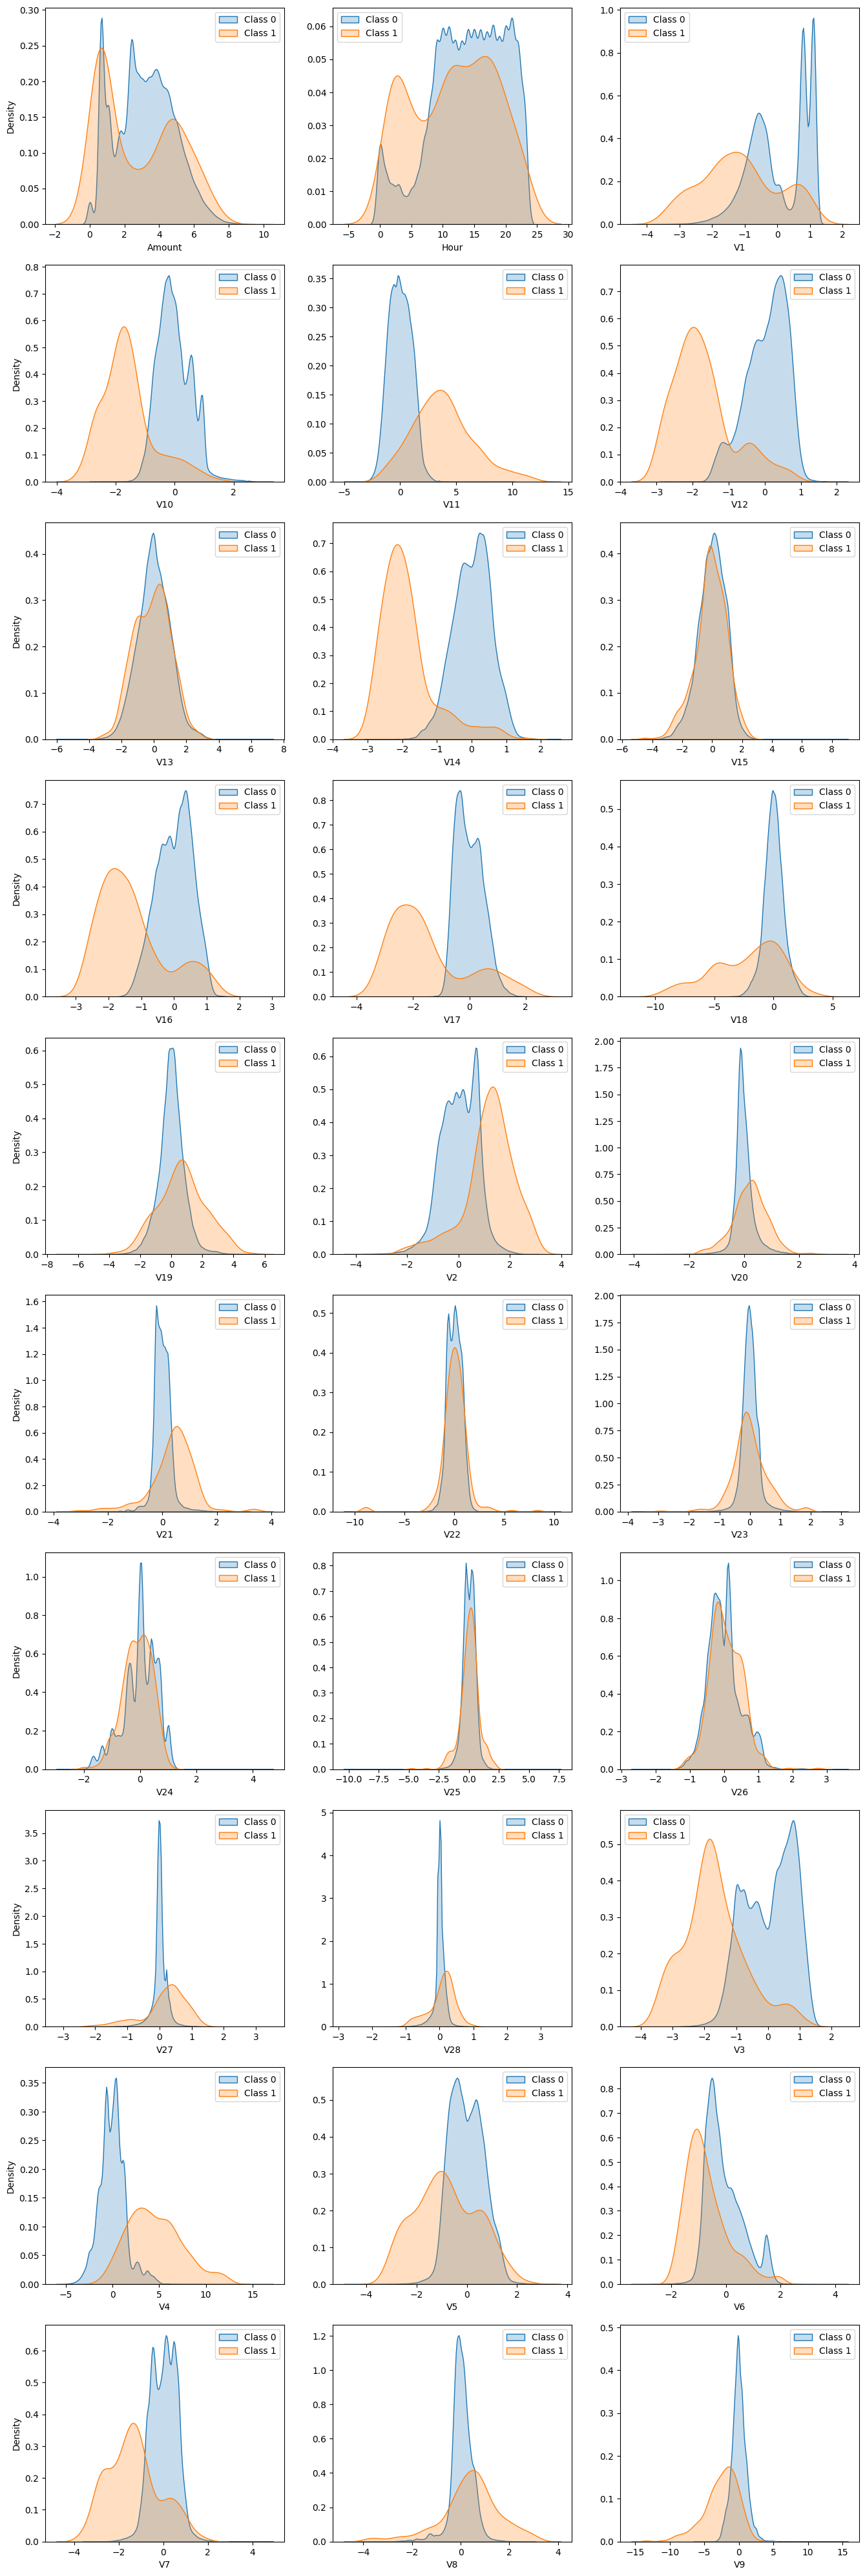

In [13]:
df_0, df_1 = df_transformed[df_transformed['Class'] == 0], df_transformed[df_transformed['Class'] == 1]
features = df_transformed.columns.difference(['Class'])
cols, ncols = list(features), 3
nrows = math.ceil(len(cols) / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))

axes = ax.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(df_0[col], ax=axes[i], label='Class 0', fill=True)
    sns.kdeplot(df_1[col], ax=axes[i], label='Class 1', fill=True)

    if i % ncols != 0:
        axes[i].set_ylabel(" ")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [14]:
cols = ['V2', 'V4', 'V7', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'Hour','Class']
df_fs = df_transformed[cols]
df_fs.head()

,V2,V4,V7,V11,V12,V14,V16,V17,V18,V19,Hour,Class
0,-0.070255,1.378155,0.214788,-0.551600,-0.481068,-0.270919,-0.385535,0.188942,0.025791,0.403993,0.0,0
1,0.235981,0.448154,-0.075852,1.612727,0.725244,-0.134332,0.381116,-0.108679,-0.183361,-0.145783,0.0,0
2,-0.850221,0.379780,0.583031,0.624501,0.063992,-0.153533,-1.358431,0.746673,-0.121359,-2.261857,0.0,0
3,-0.169933,-0.863291,0.213181,-0.226487,0.164012,-0.253031,-0.722535,-0.521227,1.965775,-1.232622,0.0,0
4,0.630067,0.403034,0.465582,-0.822843,0.430610,-0.751260,-0.372562,-0.212716,-0.038195,0.803487,0.0,0


In [15]:
X = df_fs.drop('Class', axis=1)
y = df_fs['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 11)
Target shape: (284807,)


# **Anomaly Detection using Isolation Forest**

In [16]:
# Initialize the Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=101)   # high contamination to catch more fraud transactions

# Fit the model and predict (returns -1 for anomalies and 1 for normal data)
iso_preds = iso_forest.fit_predict(X_scaled)

# Convert -1 (anomalies) to 1 (fraud) and 1 (normal) to 0 (non-fraud)
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

# Evaluate the results
print(classification_report(y, iso_preds))
roc_auc = roc_auc_score(y, iso_preds)
print("ROC AUC Score: ", roc_auc)

              precision    recall  f1-score   support

           0       1.00      0.95      0.98    284315
           1       0.03      0.90      0.06       492

    accuracy                           0.95    284807
   macro avg       0.52      0.93      0.52    284807
weighted avg       1.00      0.95      0.97    284807

ROC AUC Score:  0.9259379125323179


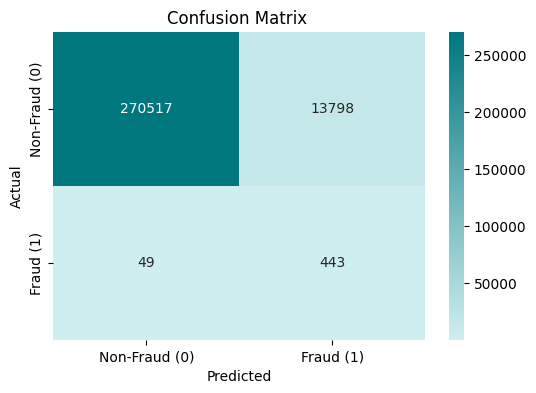

In [17]:
# Custom color palette
colors = ['#CFEEF0', '#00777F']
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Plot the confusion matrix
cm = confusion_matrix(y, iso_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

# **Anomaly Detection using AutoEncoders**

In [18]:
X = df_transformed.drop('Class', axis=1)
y = df_transformed['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")

Features shape: (284807, 30)
Target shape: (284807,)


In [19]:
# Define the autoencoder model
def define_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoded = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(input_layer)
    encoded = Dropout(0.2)(encoded)
    encoded = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(encoded)
    encoded = Dense(8, activation='relu', kernel_regularizer=l2(0.001))(encoded)

    # Latent space
    latent = Dense(4, activation='relu')(encoded)

    # Decoder
    decoded = Dense(8, activation='relu', kernel_regularizer=l2(0.001))(latent)
    decoded = Dropout(0.2)(decoded)
    decoded = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(decoded)
    decoded = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(decoded)
    output_layer = Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    return autoencoder

# Build and compile the model
autoencoder = define_autoencoder(X_scaled.shape[1])
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse')

# Train the model on normal transactions (non-fraudulent class, y == 0)
X_train = X_scaled[y == 0]
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True, validation_split=0.1)

# Calculate reconstruction error for all transactions
reconstructed = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)

# Set a threshold for anomaly detection
threshold = np.percentile(mse, 90)  # Adjust threshold (90th percentile)
autoen_preds = np.where(mse > threshold, 1, 0)  # 1: anomaly (fraud), 0: normal

# Evaluate the model
print(classification_report(y, autoen_preds))
roc_auc = roc_auc_score(y, autoen_preds)
print("ROC AUC Score: ", roc_auc)

Epoch 1/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 0.9586 - val_loss: 0.8757
Epoch 2/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 0.8700 - val_loss: 0.8525
Epoch 3/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.8376 - val_loss: 0.8284
Epoch 4/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 0.8170 - val_loss: 0.8185
Epoch 5/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 0.8072 - val_loss: 0.8111
Epoch 6/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 0.8005 - val_loss: 0.8055
Epoch 7/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.7945 - val_loss: 0.8029
Epoch 8/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 0.7895 - val_loss: 0.7978
Epoch 9/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.7848 - val_loss: 0.7907
Epoch 10/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 0.7818 - val_loss: 0.7873
Epoch 11/50
7997/7997 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 0.7779 - val_loss: 0.7864
Epoch 12/50
7997/79

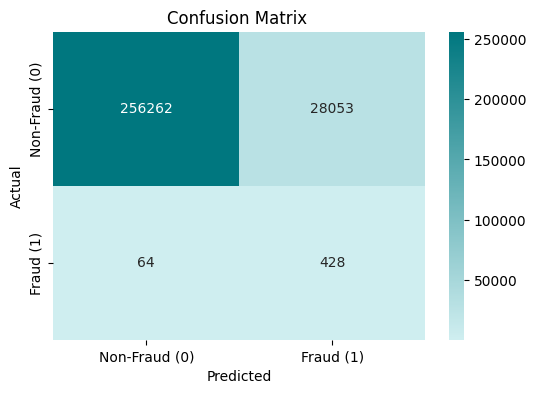

In [20]:
# Plot the confusion matrix
cm = confusion_matrix(y, autoen_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap=custom_cmap, fmt='g')

# Add labels, title, and axis ticks
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

# Exporting the Isolation Forest (Scikit-Learn)

In [21]:
!pip install tf2onnx skl2onnx onnxruntime onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 36.2 MB/s eta 0:00:00


In [27]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType
import onnx

# 1. Specify the input type
initial_type = [('float_input', FloatTensorType([None, 11]))]

# 2. Convert the model
onx = to_onnx(
    iso_forest,
    initial_types=initial_type,
    target_opset={'': 12, 'ai.onnx.ml': 3}
)

# 3. Save the model
with open("iso_forest.onnx", "wb") as f:
    f.write(onx.SerializeToString())
print("Isolation Forest exported to iso_forest.onnx")

Isolation Forest exported to iso_forest.onnx


# Exporting the Autoencoder (TensorFlow/Keras)

In [28]:
import tf2onnx
import onnx
import tensorflow as tf

# 1. Define the input signature
spec = (tf.TensorSpec((None, X_scaled.shape[1]), tf.float32, name="input"),)

# 2. Convert from Keras to ONNX
onnx_model, _ = tf2onnx.convert.from_keras(autoencoder, input_signature=spec, opset=13)

# 3. Save the model
onnx.save(onnx_model, "fraud_model.onnx")
print("Autoencoder exported to fraud_model.onnx")

Autoencoder exported to fraud_model.onnx


## Exporting the Scaler (Essential)

In [29]:
import joblib

joblib.dump(scaler, "scaler.pkl")
print("Scaler exported to scaler.pkl")

Scaler exported to scaler.pkl
